In [9]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import BackendEstimatorV2
from qiskit_aer.noise import NoiseModel

from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator

import numpy as np

In [3]:
J = 1.0
hx = -0.5

obs = SparsePauliOp.from_list([
    ("ZZ", J),
    ("XI", hx),
    ("IX", hx)
])

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

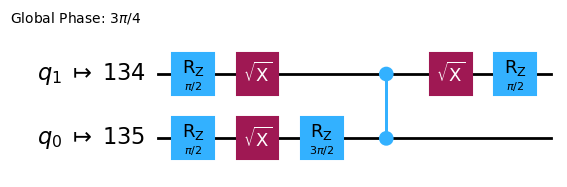

In [11]:
service = QiskitRuntimeService()
backend = service.backend("ibm_marrakesh")

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

qc_isa.draw("mpl")

In [6]:
estimator = Estimator(mode=backend)

In [13]:
pubs = [(qc_isa, obs_isa)]
# job = estimator.run(pubs=pubs)
job = service.job("d8eonbjalsvc7390kug0")
res = job.result()

In [14]:
print(res[0].data.evs)

-1.0181941073477834
